# Подгрузка библиотек

In [1]:
# основные
import numpy as np
import pandas as pd
# метрики
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, classification_report
# разбиение +валидация
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, cross_validate, GridSearchCV
# кадировки
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler # маштабирование(стандартизация)
# визуализация
import seaborn as sns
import matplotlib.pyplot as plt
# Случайный лес
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping # для ранней остановки
from catboost import CatBoostClassifier, Pool
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#  подгрузка базы


# Банк

In [4]:
# Отображать максимум 100 столбцов
pd.set_option('display.max_columns', 100)

In [5]:
df1 = pd.read_csv('bank.csv',sep =";")  # смотреть есть заем или нет  Y= loan
df1

,age,job,marital,education,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,default
0,58,management,married,tertiary,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,no
1,44,technician,single,secondary,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,no
2,33,entrepreneur,married,secondary,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,no
3,47,blue-collar,married,unknown,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,no
4,33,unknown,single,unknown,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes,no
45207,71,retired,divorced,primary,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes,no
45208,72,retired,married,secondary,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes,no
45209,57,blue-collar,married,secondary,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no,no


Подготовка базы

In [6]:
# удаление дубликатов
df1 = df1.drop_duplicates()

In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   balance    45211 non-null  int64 
 5   housing    45211 non-null  object
 6   loan       45211 non-null  object
 7   contact    45211 non-null  object
 8   day        45211 non-null  int64 
 9   month      45211 non-null  object
 10  duration   45211 non-null  int64 
 11  campaign   45211 non-null  int64 
 12  pdays      45211 non-null  int64 
 13  previous   45211 non-null  int64 
 14  poutcome   45211 non-null  object
 15  deposit    45211 non-null  object
 16  default    45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [8]:
cols = df1.columns #  получаем имена  колонок

for i in range(len(cols)):              # запускаем цикл
    x = cols[i]                         # получаем имя определенной колонки из цикла
    print('Характеристика:', cols[i])   # печатаем имя
    kol_un = len(df1[x].unique())        # получаем  расчет уникальных значений этой колонки
    print('Количество уникальных значений:', kol_un )   # печатаем уник. значение
    kol_val = df1[x].value_counts()      # получаем список значений для колонки из цикла
    print('Список значений:', '\n' , kol_val  )  # печатаем список значений
    print()                             # визуально разделяем друг от друга


Характеристика: age
Количество уникальных значений: 77
Список значений: 
 age
32    2085
31    1996
33    1972
34    1930
35    1894
      ... 
95       2
93       2
92       2
88       2
94       1
Name: count, Length: 77, dtype: int64

Характеристика: job
Количество уникальных значений: 12
Список значений: 
 job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

Характеристика: marital
Количество уникальных значений: 3
Список значений: 
 marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

Характеристика: education
Количество уникальных значений: 4
Список значений: 
 education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

Характеристика: balance
Количество 

# Визуализация

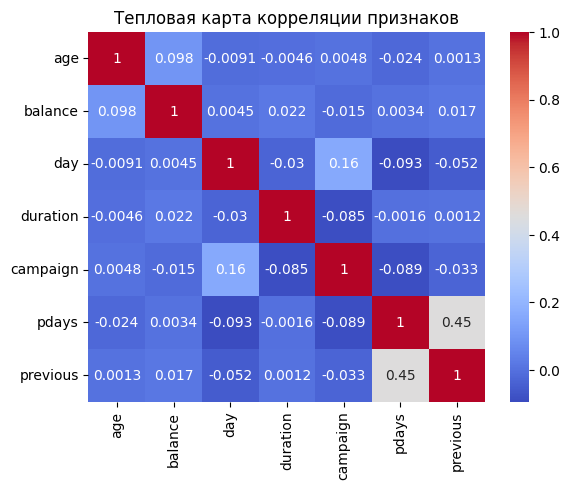

In [9]:
correlation_matrix = df1.corr(numeric_only=True) # Убираем предупреждение о нечисловых типах
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm") # annot - показывать значения корреляции
plt.title("Тепловая карта корреляции признаков")
plt.show()

# Кодировка  фичей

Используем LabelEncoder  для бинарных столбцов





In [10]:
# Обучим LabelEncoder
label_encoder = LabelEncoder()

In [11]:
# Обучим LabelEncoder на столбце 'цвет' и преобразуем его
label_encoder = LabelEncoder()
df1['loan'] = label_encoder.fit_transform(df1['loan'])


In [12]:
df1['deposit'] = label_encoder.fit_transform(df1['deposit'])

In [13]:
df1['default'] = label_encoder.fit_transform(df1['default'])

In [14]:
df1['housing'] = label_encoder.fit_transform(df1['housing'])

In [15]:
df1['month'] = label_encoder.fit_transform(df1['month'])

In [16]:
df1

,age,job,marital,education,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,default
0,58,management,married,tertiary,2143,1,0,unknown,5,8,261,1,-1,0,unknown,0,0
1,44,technician,single,secondary,29,1,0,unknown,5,8,151,1,-1,0,unknown,0,0
2,33,entrepreneur,married,secondary,2,1,1,unknown,5,8,76,1,-1,0,unknown,0,0
3,47,blue-collar,married,unknown,1506,1,0,unknown,5,8,92,1,-1,0,unknown,0,0
4,33,unknown,single,unknown,1,0,0,unknown,5,8,198,1,-1,0,unknown,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,825,0,0,cellular,17,9,977,3,-1,0,unknown,1,0
45207,71,retired,divorced,primary,1729,0,0,cellular,17,9,456,2,-1,0,unknown,1,0
45208,72,retired,married,secondary,5715,0,0,cellular,17,9,1127,5,184,3,success,1,0
45209,57,blue-collar,married,secondary,668,0,0,telephone,17,9,508,4,-1,0,unknown,0,0


In [17]:
# уменьшим количество уникальных значений объединив unknown с  other
df1.loc[(df1.poutcome =='unknown'), 'poutcome'] = 'other'

In [18]:
# просмотр уникальных значений в столбце в список чтоб можно было копировать
df1['poutcome'].unique()

array(['other', 'failure', 'success'], dtype=object)

In [19]:
# Получаем список колонок для копирования
cols = df1.columns
cols

Index(['age', 'job', 'marital', 'education', 'balance', 'housing', 'loan',
       'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous',
       'poutcome', 'deposit', 'default'],
      dtype='object')

Осталось 5 категориальных столбцов 'job', 'marital', 'education', 'contact', 'poutcome' из которых 'contact' удалим

In [20]:
df1 = pd.get_dummies(df1, columns=['job', 'marital', 'education', 'poutcome' ], drop_first= True )

In [21]:
df1

,age,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,deposit,default,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,poutcome_other,poutcome_success
0,58,2143,1,0,unknown,5,8,261,1,-1,0,0,0,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,False
1,44,29,1,0,unknown,5,8,151,1,-1,0,0,0,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,True,False
2,33,2,1,1,unknown,5,8,76,1,-1,0,0,0,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False
3,47,1506,1,0,unknown,5,8,92,1,-1,0,0,0,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False
4,33,1,0,0,unknown,5,8,198,1,-1,0,0,0,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,825,0,0,cellular,17,9,977,3,-1,0,1,0,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,True,False
45207,71,1729,0,0,cellular,17,9,456,2,-1,0,1,0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
45208,72,5715,0,0,cellular,17,9,1127,5,184,3,1,0,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,True
45209,57,668,0,0,telephone,17,9,508,4,-1,0,0,0,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False


In [22]:
# удалить столбцы категориальные которые не нужно
df1 = df1.drop(columns=['contact'])

In [23]:
df1

,age,balance,housing,loan,day,month,duration,campaign,pdays,previous,deposit,default,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,poutcome_other,poutcome_success
0,58,2143,1,0,5,8,261,1,-1,0,0,0,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,False
1,44,29,1,0,5,8,151,1,-1,0,0,0,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,True,False
2,33,2,1,1,5,8,76,1,-1,0,0,0,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False
3,47,1506,1,0,5,8,92,1,-1,0,0,0,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False
4,33,1,0,0,5,8,198,1,-1,0,0,0,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,825,0,0,17,9,977,3,-1,0,1,0,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,True,False
45207,71,1729,0,0,17,9,456,2,-1,0,1,0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
45208,72,5715,0,0,17,9,1127,5,184,3,1,0,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,True
45209,57,668,0,0,17,9,508,4,-1,0,0,0,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False


In [24]:
# Если целевой столбец во float переводим в int!!!
#df['loan'] = df['loan'].astype(int) # у нас он  0/1  int   поэтому здесь не запускаем

 # Разделение на X и Y

In [25]:
# Подготовка фичей - в X  удаляем колонку предсказания категории цены
X= df1.drop(['loan'], axis=1)
#подготовка целевой переменны-  в Y  только колонка предсказания категории цены
y = df1['loan']

In [26]:
# проверяем  45211 строк и 30-1=29 столбцов
X.shape

(45211, 29)

# Маштабирование Х

In [27]:
# Создадим экземпляр StandardScaler
scaler = StandardScaler()

# Обучим StandardScaler на данных и преобразуем их
df_scaled = scaler.fit_transform(X)

# Преобразуем в DataFrame
X = pd.DataFrame(df_scaled, columns=X.columns)

In [28]:
X

,age,balance,housing,day,month,duration,campaign,pdays,previous,deposit,default,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,poutcome_other,poutcome_success
0,1.606965,0.256419,0.893915,-1.298476,0.823773,0.011016,-0.569351,-0.411453,-0.251940,-0.363983,-0.13549,-0.523740,-0.184415,-0.16793,1.944270,-0.229600,-0.190234,-0.318082,-0.145557,-0.449414,-0.172266,-0.080069,0.813212,-0.628090,-1.026745,1.548892,-0.206962,0.406524,-0.185948
1,0.288529,-0.437895,0.893915,-1.298476,0.823773,-0.416127,-0.569351,-0.411453,-0.251940,-0.363983,-0.13549,-0.523740,-0.184415,-0.16793,-0.514332,-0.229600,-0.190234,-0.318082,-0.145557,2.225121,-0.172266,-0.080069,-1.229691,1.592128,0.973952,-0.645623,-0.206962,0.406524,-0.185948
2,-0.747384,-0.446762,0.893915,-1.298476,0.823773,-0.707361,-0.569351,-0.411453,-0.251940,-0.363983,-0.13549,-0.523740,5.422561,-0.16793,-0.514332,-0.229600,-0.190234,-0.318082,-0.145557,-0.449414,-0.172266,-0.080069,0.813212,-0.628090,0.973952,-0.645623,-0.206962,0.406524,-0.185948
3,0.571051,0.047205,0.893915,-1.298476,0.823773,-0.645231,-0.569351,-0.411453,-0.251940,-0.363983,-0.13549,1.909346,-0.184415,-0.16793,-0.514332,-0.229600,-0.190234,-0.318082,-0.145557,-0.449414,-0.172266,-0.080069,0.813212,-0.628090,-1.026745,-0.645623,4.831796,0.406524,-0.185948
4,-0.747384,-0.447091,-1.118674,-1.298476,0.823773,-0.233620,-0.569351,-0.411453,-0.251940,-0.363983,-0.13549,-0.523740,-0.184415,-0.16793,-0.514332,-0.229600,-0.190234,-0.318082,-0.145557,-0.449414,-0.172266,12.489301,-1.229691,1.592128,-1.026745,-0.645623,4.831796,0.406524,-0.185948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,0.947747,-0.176460,-1.118674,0.143418,1.156344,2.791329,0.076230,-0.411453,-0.251940,2.747384,-0.13549,-0.523740,-0.184415,-0.16793,-0.514332,-0.229600,-0.190234,-0.318082,-0.145557,2.225121,-0.172266,-0.080069,0.813212,-0.628090,-1.026745,1.548892,-0.206962,0.406524,-0.185948
45207,2.831227,0.120447,-1.118674,0.143418,1.156344,0.768224,-0.246560,-0.411453,-0.251940,2.747384,-0.13549,-0.523740,-0.184415,-0.16793,-0.514332,4.355402,-0.190234,-0.318082,-0.145557,-0.449414,-0.172266,-0.080069,-1.229691,-0.628090,-1.026745,-0.645623,-0.206962,0.406524,-0.185948
45208,2.925401,1.429593,-1.118674,0.143418,1.156344,3.373797,0.721811,1.436189,1.050473,2.747384,-0.13549,-0.523740,-0.184415,-0.16793,-0.514332,4.355402,-0.190234,-0.318082,-0.145557,-0.449414,-0.172266,-0.080069,0.813212,-0.628090,0.973952,-0.645623,-0.206962,-2.459878,5.377848
45209,1.512791,-0.228024,-1.118674,0.143418,1.156344,0.970146,0.399020,-0.411453,-0.251940,-0.363983,-0.13549,1.909346,-0.184415,-0.16793,-0.514332,-0.229600,-0.190234,-0.318082,-0.145557,-0.449414,-0.172266,-0.080069,0.813212,-0.628090,0.973952,-0.645623,-0.206962,0.406524,-0.185948


 # Разделение на train и text

In [29]:
# Разбиваем на  обучающую и тестовую
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [30]:
X_train.shape

(31647, 29)

In [31]:
X_test.shape

(13564, 29)

In [32]:
#  Обучение  дерева решений
tree = DecisionTreeClassifier(max_depth= 5, min_samples_leaf=1, min_samples_split= 2, random_state=42)
tree.fit(X_train, y_train)

# Оценка модели
y_pred_tree_t = tree.predict(X_train)
y_pred_tree = tree.predict(X_test)

accuracy_tree_t = accuracy_score(y_train, y_pred_tree_t)
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print(f"Дерево решений : Accuracy train = {accuracy_tree_t:.2f}")
print(f"Дерево решений : Accuracy test = {accuracy_tree:.2f}")
print("\nClassification Report :\n", classification_report(y_test, y_pred_tree))


Дерево решений : Accuracy train = 0.84
Дерево решений : Accuracy test = 0.84

Classification Report :
               precision    recall  f1-score   support

           0       0.84      0.99      0.91     11398
           1       0.54      0.04      0.07      2166

    accuracy                           0.84     13564
   macro avg       0.69      0.52      0.49     13564
weighted avg       0.80      0.84      0.78     13564



In [33]:
# Случайный лес для классификации (без GridSearchCV, с заданными параметрами)
rf = RandomForestClassifier(n_estimators=150,  # Задаем количество деревьев
                            max_depth=6,       # Задаем максимальную глубину
                            min_samples_split=5, # Задаем минимальное количество образцов для разделения
                            min_samples_leaf=3,  # Задаем минимальное количество образцов в листе
                            random_state=42)    # Задаем зерно для воспроизводимости

rf.fit(X_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,6
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
#  Оценка модели
y_pred_rf_t = rf.predict(X_train)
y_pred_rf = rf.predict(X_test)

accuracy_rf_t = accuracy_score(y_train, y_pred_rf_t)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Случайный лес: Accuracy train= {accuracy_rf_t:.2f}")
print(f"Случайный лес: Accuracy test = {accuracy_rf:.2f}")
print("\nClassification Report (Случайный лес):\n", classification_report(y_test, y_pred_rf))

Случайный лес: Accuracy train= 0.84
Случайный лес: Accuracy test = 0.84

Classification Report (Случайный лес):
               precision    recall  f1-score   support

           0       0.84      1.00      0.91     11398
           1       0.00      0.00      0.00      2166

    accuracy                           0.84     13564
   macro avg       0.42      0.50      0.46     13564
weighted avg       0.71      0.84      0.77     13564



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [37]:
# Случайный лес для классификации
param_grid = {'n_estimators': [50, 100, 200],  # Количество деревьев
              'max_depth': [4, 6, 8],       # Максимальная глубина дерева
              'min_samples_split': [2, 5, 10], # Минимальное количество образцов для разделения
              'min_samples_leaf': [1, 3, 5]}   # Минимальное количество образцов в листе

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train) # Обучаем на масштабированных данных (хотя это и не обязательно)

# Лучшая модель
best_rf = grid_search.best_estimator_
print("Лучшие параметры для случайного леса:", grid_search.best_params_)



Лучшие параметры для случайного леса: {'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 50}


# XGBoost

## XGBoost просто

In [47]:
#  Масштабирование признаков (рекомендуется для XGBoost)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
# XGBoost для классификации
xgb = XGBClassifier(
    n_estimators=50,      # Количество деревьев (boosting rounds)
    learning_rate=0.1,     # Темп обучения (шаг градиентного спуска)0.001
    max_depth=3,           # Максимальная глубина дерева
    subsample=0.5,         # Доля образцов для обучения каждого дерева
    colsample_bytree=0.5,  # Доля признаков для обучения каждого дерева
    random_state=42,       # Зерно для воспроизводимости
    use_label_encoder=False, # Чтобы избежать предупреждения
    eval_metric='logloss'  # Метрика для оценки производительности (обязательно указать)
)

xgb.fit(X_train, y_train)



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [20:09:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [49]:
#  Оценка модели
y_pred_xgb_t = xgb.predict(X_train)
y_pred_xgb = xgb.predict(X_test)

accuracy_xgb_t = accuracy_score(y_train, y_pred_xgb_t)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost: Accuracy train = {accuracy_xgb_t:.2f}")
print(f"XGBoost: Accuracy test = {accuracy_xgb:.2f}")

print("\nClassification Report (train):\n", classification_report(y_train, y_pred_xgb_t))
print("\nClassification Report (test):\n", classification_report(y_test, y_pred_xgb))

XGBoost: Accuracy train = 0.84
XGBoost: Accuracy test = 0.84

Classification Report (train):
               precision    recall  f1-score   support

           0       0.84      1.00      0.91     26569
           1       0.66      0.02      0.04      5078

    accuracy                           0.84     31647
   macro avg       0.75      0.51      0.48     31647
weighted avg       0.81      0.84      0.77     31647


Classification Report (test):
               precision    recall  f1-score   support

           0       0.84      1.00      0.91     11398
           1       0.66      0.01      0.03      2166

    accuracy                           0.84     13564
   macro avg       0.75      0.51      0.47     13564
weighted avg       0.81      0.84      0.77     13564



In [50]:
# Предсказание для нового клиента
new_income = 60000
new_credit_history = 0.7

new_client = pd.DataFrame({'income': [new_income], 'credit_history': [new_credit_history]})
new_client_scaled = scaler.transform(new_client)

loan_decision_new_client = xgb.predict(new_client_scaled)[0]
probability_of_loan_new_client = xgb.predict_proba(new_client_scaled)[0, 1]

print(f"\nПредсказание для нового клиента:")
print(f"Доход: {new_income}, Кредитная история: {new_credit_history}")
print(f"Вероятность выдачи кредита: {probability_of_loan_new_client:.2f}")
print(f"Решение о выдаче кредита (1 - выдать, 0 - выдать): {loan_decision_new_client}")

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- credit_history
- income
Feature names seen at fit time, yet now missing:
- age
- balance
- campaign
- day
- default
- ...


In [40]:
#  XGBoost
param_grid = {
    'n_estimators': [50, 100, 200],       # Количество деревьев
    'learning_rate': [0.01, 0.1],   # Темп обучения
    'max_depth': [3, 5],             # Максимальная глубина дерева
    'subsample': [0.7, 0.9],        # Доля образцов для обучения
    'colsample_bytree': [0.7,  0.9]   # Доля признаков для обучения
}
# создаем объект RandomizedSearchCV
random_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_iter=10,  # Количество случайных комбинаций для перебора
    verbose=0
)

random_search.fit(X_train, y_train)



,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.9], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5], 'n_estimators': [50, 100, ...], ...}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [41]:
# Лучшая модель
best_xgb = random_search.best_estimator_
print("Лучшие параметры для XGBoost:", random_search.best_params_)

Лучшие параметры для XGBoost: {'subsample': 0.9, 'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


In [42]:
# Оценка модели
y_pred_xgb_t = best_xgb.predict(X_train)
y_pred_xgb = best_xgb.predict(X_test)

accuracy_xgb_t = accuracy_score(y_train, y_pred_xgb_t)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost: Accuracy train = {accuracy_xgb_t:.2f}")
print(f"XGBoost: Accuracy = {accuracy_xgb:.2f}")

print("\nClassification Report train:\n", classification_report(y_train, y_pred_xgb_t))
print("\nClassification Report text:\n", classification_report(y_test, y_pred_xgb))

XGBoost: Accuracy train = 0.84
XGBoost: Accuracy = 0.84

Classification Report train:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91     26569
           1       0.70      0.04      0.08      5078

    accuracy                           0.84     31647
   macro avg       0.77      0.52      0.50     31647
weighted avg       0.82      0.84      0.78     31647


Classification Report text:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91     11398
           1       0.64      0.03      0.06      2166

    accuracy                           0.84     13564
   macro avg       0.74      0.51      0.49     13564
weighted avg       0.81      0.84      0.78     13564



In [ ]:
#  Предсказание для нового клиента
new_income = 60000
new_credit_history = 0.7

new_client = pd.DataFrame({'income': [new_income], 'credit_history': [new_credit_history]})
new_client_scaled = scaler.transform(new_client)

loan_decision_new_client = best_xgb.predict(new_client_scaled)[0]
probability_of_loan_new_client = best_xgb.predict_proba(new_client_scaled)[0, 1]

print(f"\nПредсказание для нового клиента:")
print(f"Доход: {new_income}, Кредитная история: {new_credit_history}")
print(f"Вероятность выдачи кредита: {probability_of_loan_new_client:.2f}")
print(f"Решение о выдаче кредита (1 - выдать, 0 - выдать): {loan_decision_new_client}")